In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pressure = pd.read_csv('pressure_at0.csv') #values at the inlet
data = pd.read_csv('velocity_outlet.csv') # values at the outlet

data = data.dropna()
data.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
217,0.000738,2.501100e-12,-0.000029,0.064952,1,0.001736,0,-0.002264,0.034485
218,0.000694,2.501100e-12,-0.000029,0.068380,1,0.001744,0,-0.002256,0.034485
219,0.000649,2.501100e-12,-0.000028,0.071809,1,0.001752,0,-0.002248,0.034485
220,0.000605,2.501100e-12,-0.000027,0.075237,1,0.001760,0,-0.002240,0.034485
221,0.000560,2.501100e-12,-0.000026,0.078665,1,0.001768,0,-0.002232,0.034485


In [3]:
pressure.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
0,0.55014,0.000000e+00,0.000000e+00,0.52165,1,0.000000,0,0,0.000000
1,0.54995,-1.241200e-20,-2.385200e-20,0.52208,1,0.000034,0,0,0.000034
2,0.54976,-2.482400e-20,-4.770500e-20,0.52251,1,0.000069,0,0,0.000069
3,0.54957,-3.723600e-20,-7.155700e-20,0.52294,1,0.000103,0,0,0.000103
4,0.54938,-4.964800e-20,-9.541000e-20,0.52337,1,0.000138,0,0,0.000138


In [4]:
p = pressure['p'].mean() #pressure['p'][0]
length = 0.034485

pressureGrad = p/length
pressureGrad

6.878601912224358

In [5]:
#reynolds number
R = 0.00227 #radius
rho = 1.0 #density
Re = rho*0.52*R*2/(1.48e-05)#Reynolds number
print(Re)

159.51351351351352


In [6]:
f = 64/Re
print(f)

0.4012199254490003


In [7]:
dP = f*length*1*0.52**2/(2*R*2)
pressureGrad = dP/length
pressureGrad


11.94822333055173

In [8]:
dPdx = 1.48e-05*4/(0.00227**2)
dPdx

11.488676279376664

In [9]:
data['U'] = np.sqrt(data['U:1']**2 + data['U:2']**2 + data['U:0']**2) # velocity magnitude

data['r'] = np.sqrt(data['Points:0']**2 + data['Points:1']**2) # array how radius changing

data.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2,U,r
217,0.000738,2.501100e-12,-0.000029,0.064952,1,0.001736,0,-0.002264,0.034485,0.064952,0.002264
218,0.000694,2.501100e-12,-0.000029,0.068380,1,0.001744,0,-0.002256,0.034485,0.068380,0.002256
219,0.000649,2.501100e-12,-0.000028,0.071809,1,0.001752,0,-0.002248,0.034485,0.071809,0.002248
220,0.000605,2.501100e-12,-0.000027,0.075237,1,0.001760,0,-0.002240,0.034485,0.075237,0.002240
221,0.000560,2.501100e-12,-0.000026,0.078665,1,0.001768,0,-0.002232,0.034485,0.078665,0.002232


In [10]:
r1 = np.linspace(-0.00227,0.00227,1000)
#data['exp']=(data['r']**2-R**2)*(1*rho/(4*1.48e-05))*pressureGrad 

data['exp']=(R**2-data['r']**2)*(1/(4*1.48e-05))*pressureGrad 
res=(R**2-r1**2)*(1/(4*1.48e-05))*pressureGrad 

In [11]:
x = np.arange(0,567,1)
x2 = np.linspace(0,567,1000)

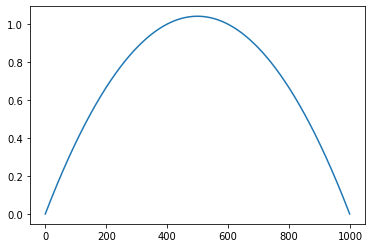

In [12]:
plt.plot(res);

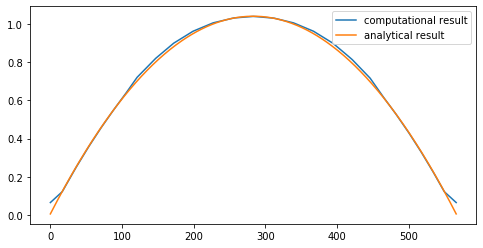

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(x, data['U'],label = 'computational result')
plt.plot(x,data['exp'], label = 'analytical result')
plt.legend(loc="upper right");
#plt.plot(x2,res);


Another parameter which we can compare is the average velocity, which should be equal $v_{avg} = v_{max}/2$

In [16]:
v_max = data['U'].max()
v_avg = v_max/2
v_avg

0.51955

In [20]:
v_initial = 0.0521646
diff = 100-(100*0.5196/(0.521646))
print('differenece between calculated velocity and analytical velocity is:',round(diff,4),'%')

differenece between calculated velocity and analytical velocity is: 0.3922 %
